Build a baseline linear regression using estimated_median_gross_rent as the target. Evaluate it with R², RMSE, MAE, and residual plots.
Build one alternative regression model, likely Random Forest, then compare performance and feature importance. This gives us two supervised models without changing the project direction.
Use the better regression model to calculate residuals. Tracts with actual rent below predicted rent become “lower-than-expected rent” candidates for closer review.
Run K-means clustering on the 727 scaled tracts. Test several values of K using inertia/elbow and silhouette score, then profile and name the clusters.
Cross-reference the strongest negative-residual tracts with their cluster types and SDPD safety information where available.
Finish with a model comparison table, tract-level results, interpretation, limitations, and a saved final results dataset.

# San Diego Neighborhood Opportunity Finder: Modeling

I’m looking at two different ways to understand San Diego County census tracts.

   1. I'm going do a regression model to estimate `estimated_median_gross_rent` based on the tract features selected from preprocessing. I can compare Linear Regression and Random Forest, then use whichever model is stronger to find tracts where actual rent is lower than the model expected.

   2. I’ll do K-means clustering to group tracts with similar demographic, transportation, housing, school, and environmental conditions. The clusters can illustrate different neighborhood types that might be better suited for different types of development.

My goal with the model is to treat it as a screening tool for urban planners, real estate developers, or investors looking into different tracts for growth opportunity.

### Process Breakdown

   1. Baseline linear regression model using estimated_median_gross_rent as the target. Evaluate with R², RMSE, MAE, and residual plots.
   2. Random Forest, then compare performance and feature importance.
   3. Use the better regression model to calculate residuals. Tracts with actual rent below predicted rent become “lower-than-expected rent” candidates for closer review.
   4. Run K-means clustering for 727 scaled tracts. Test different values of K using inertia/elbow and silhouette score, then profile and name the clusters
   5. Cross-reference the strongest negative-residual tracts with the cluster types and SDPD safety information.
   6. Model comparison table, tract-level results, interpretation, limitations, and final results dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_cluster = pd.read_csv('../data/processed/X_cluster_scaled.csv')

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('X_cluster:', X_cluster.shape)

X_train: (581, 21)
X_test: (146, 21)
y_train: (581, 2)
y_test: (146, 2)
X_cluster: (727, 21)


In [3]:
# dropping the index column
for df in [X_train, X_test, y_train, y_test, X_cluster]:
    df.drop(columns='Unnamed: 0', inplace=True)

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('X_cluster:', X_cluster.shape)

X_train: (581, 20)
X_test: (146, 20)
y_train: (581,)
y_test: (146,)
X_cluster: (727, 20)


In [4]:
features = [
    'walkability_index', 'public_transit_commute_rate', 'no_vehicle_rate', 'work_from_home_rate',
    'climate_loss_risk_score', 'heat_risk_score', 'flood_risk_score', 'wildfire_risk_score',
    'social_vulnerability_score', 'school_academic_score', 'median_household_income', 'poverty_rate',
    'unemployment_rate', 'renter_rate', 'vacancy_rate', 'population_under_18_rate',
    'avg_household_size', 'median_age', 'transit_stop_density_log', 'school_density_log']

## Linear Regression

In [5]:
# baseline regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

In [6]:
linear_metrics = {
    'train_r2': r2_score(y_train, train_pred),
    'test_r2': r2_score(y_test, test_pred),
    'train_rmse': mean_squared_error(y_train, train_pred) ** 0.5,
    'test_rmse': mean_squared_error(y_test, test_pred) ** 0.5,
    'train_mae': mean_absolute_error(y_train, train_pred),
    'test_mae': mean_absolute_error(y_test, test_pred)}

pd.Series(linear_metrics).round(3)

train_r2        0.504
test_r2         0.566
train_rmse    365.946
test_rmse     364.386
train_mae     279.190
test_mae      277.743
dtype: float64

## Linear Regression Results

The baseline Linear Regression explains around 57% of the variation for estimated median gross rent on the test data.

Test RMSE is about `$364` and the MAE is about `$278`, meaning the model's rent estimates are off by a few hundred dollars.

Training and test results are really close, so it doesn't look like the model is overfitting. It's a good baseline to work off of. 


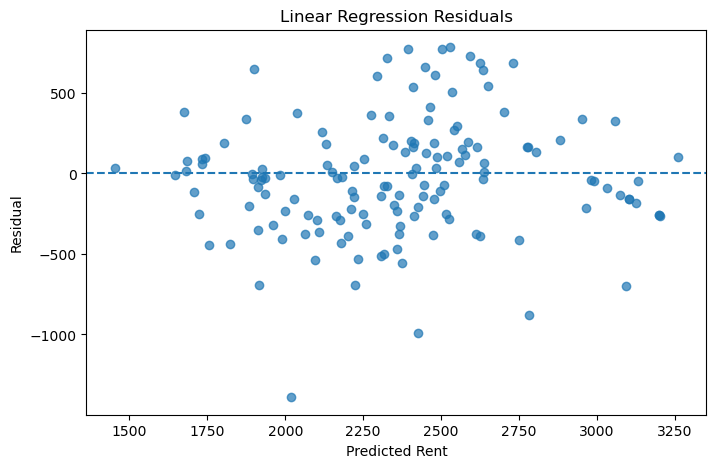

In [7]:
test_residuals = y_test - test_pred

plt.figure(figsize=(8, 5))
plt.scatter(test_pred, test_residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Rent')
plt.ylabel('Residual')
plt.title('Linear Regression Residuals')
plt.show()

### Residuals

The residuals are mostly spread around zero, so the model wasn't too far off from actual rents, but it's not perfect either. There were some really large negative residuals, meaning the actual rent is much lower than the predicted rent. I'm curious why that is and what specific features are driving those predictions -- will review later in clustering.


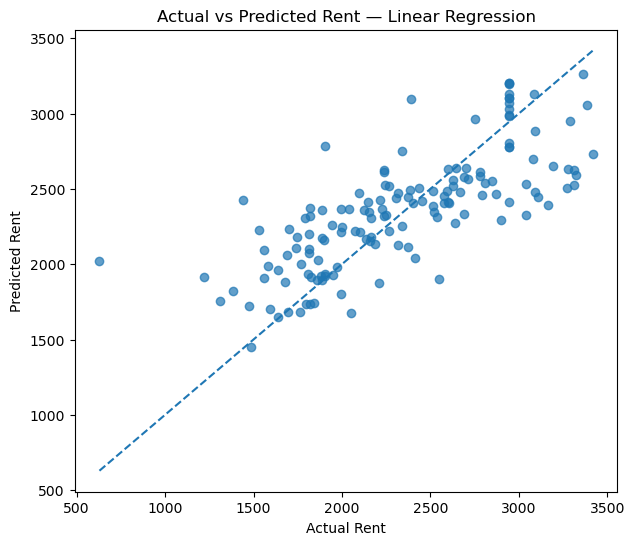

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rent — Linear Regression')
plt.show()

### Actual vs Predicted Rent

The predictions generally move in the same direction as actual rent, but the model isn't as good at predicting very high/very low rents. It can grasp the general pattern, but not every tract. 


## Feature Importance

In [9]:
linear_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': linear_model.coef_})

# sorting by absolute size so the strongest effects show first
linear_importance['importance'] = linear_importance['coefficient'].abs()

linear_importance.sort_values(
    'importance',
    ascending=False).round(2)

,feature,coefficient,importance
10,median_household_income,231.51,231.51
4,climate_loss_risk_score,-134.02,134.02
6,flood_risk_score,130.51,130.51
5,heat_risk_score,-64.59,64.59
9,school_academic_score,60.22,60.22
17,median_age,-56.01,56.01
16,avg_household_size,-54.99,54.99
12,unemployment_rate,-47.16,47.16
8,social_vulnerability_score,-43.75,43.75
2,no_vehicle_rate,-39.23,39.23


The biggest obvious relationship is between median income and estimated gross median rent, but I think everything below it is pretty interesting. It looks like environmental factors and school scores play a big role in the model determining rental prices. Now that we can see some of the features related to price, I wonder what would happen if i changed the target from rental price to something like school scores or unemployment rate, to see what contributing factors might be. 

C:\Users\cococ\AppData\Local\Temp\ipykernel_37224\4039872301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


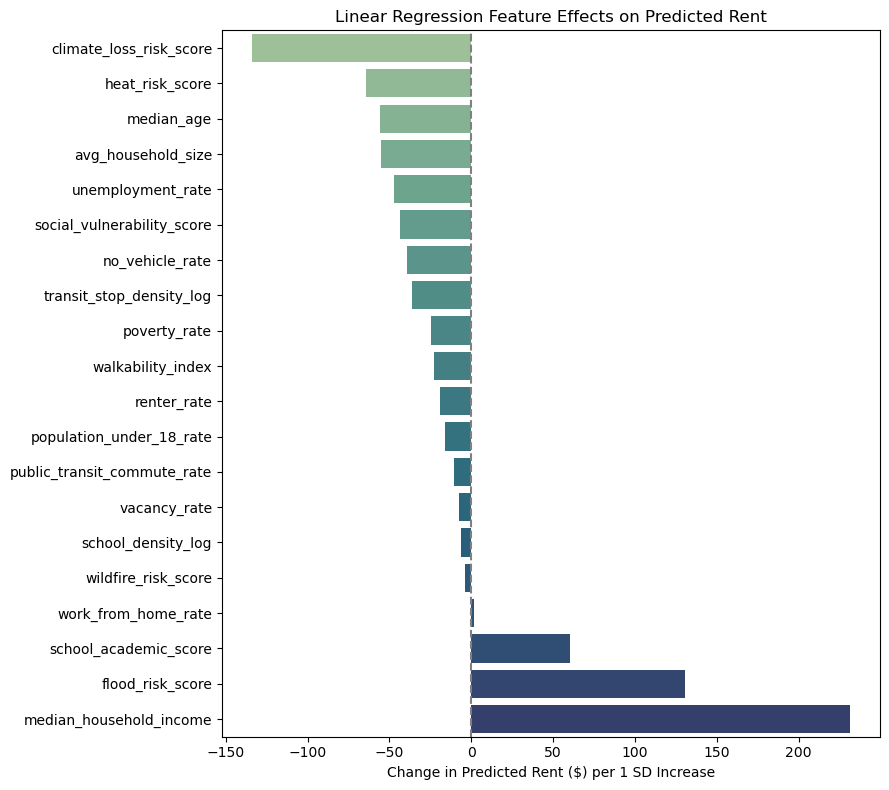

In [10]:
coef_plot = linear_importance.sort_values('coefficient')

plt.figure(figsize=(9, 8))

sns.barplot(
    data=coef_plot,
    x='coefficient',
    y='feature',
    palette='crest')

plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Change in Predicted Rent ($) per 1 SD Increase')
plt.ylabel('')
plt.title('Linear Regression Feature Effects on Predicted Rent')
plt.tight_layout()
plt.show()

## Random Forest

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

In [12]:
rf_metrics = {
    'train_r2': r2_score(y_train, rf_train_pred),
    'test_r2': r2_score(y_test, rf_test_pred),
    'train_rmse': mean_squared_error(y_train, rf_train_pred) ** 0.5,
    'test_rmse': mean_squared_error(y_test, rf_test_pred) ** 0.5,
    'train_mae': mean_absolute_error(y_train, rf_train_pred),
    'test_mae': mean_absolute_error(y_test, rf_test_pred)}

pd.Series(rf_metrics).round(3)

train_r2        0.924
test_r2         0.543
train_rmse    142.820
test_rmse     374.049
train_mae     104.903
test_mae      275.098
dtype: float64

### Random Forest Results

The Random Forest fits the training data really well with an R2 of 0.92, but the test R2 drops to 0.54 which means it's probably overfitting. 

Its test RMSE is about `$374` and MAE is about `$275` which is pretty similar to the linear regression model results.

I'm curious to see if the model improves with some limits on tree depth or leaf size, so I'll try tuning before choosing the final regression model.


## RF Tuning

In [13]:
from sklearn.model_selection import GridSearchCV

# testing several RF settings using only the training data
# cross-validation splits the training data into smaller train/validation folds
param_grid = {
    'n_estimators': [200, 300, 500],      # number of trees in the forest
    'max_depth': [5, 8, 12, None],        # tree complexity
    'min_samples_leaf': [1, 3, 5, 10]}     # larger numbers stop trees from fitting small groups

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1),
    param_grid=param_grid,
    cv=5,         # testing on 5 training folds
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

rf_grid.fit(X_train, y_train)

print('Best parameters:', rf_grid.best_params_)
print('Best CV RMSE:', round(-rf_grid.best_score_, 2))

Best parameters: {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 500}
Best CV RMSE: 372.15


In [14]:
# using the best RF found from training-only cross-validation
best_rf = rf_grid.best_estimator_

# final test-set predictions
rf_train_pred = best_rf.predict(X_train)
rf_test_pred = best_rf.predict(X_test)

# comparing train and test performance after tuning
rf_metrics = {
    'train_r2': r2_score(y_train, rf_train_pred),
    'test_r2': r2_score(y_test, rf_test_pred),
    'train_rmse': mean_squared_error(y_train, rf_train_pred) ** 0.5,
    'test_rmse': mean_squared_error(y_test, rf_test_pred) ** 0.5,
    'train_mae': mean_absolute_error(y_train, rf_train_pred),
    'test_mae': mean_absolute_error(y_test, rf_test_pred)}

pd.Series(rf_metrics).round(3)

train_r2        0.696
test_r2         0.535
train_rmse    286.355
test_rmse     377.405
train_mae     208.182
test_mae      281.137
dtype: float64

In [15]:
model_comparison = pd.DataFrame({
    'model': ['Linear Regression', 'Tuned Random Forest'],
    'train_r2': [linear_metrics['train_r2'], rf_metrics['train_r2']],
    'test_r2': [linear_metrics['test_r2'], rf_metrics['test_r2']],
    'test_rmse': [linear_metrics['test_rmse'], rf_metrics['test_rmse']],
    'test_mae': [linear_metrics['test_mae'], rf_metrics['test_mae']]})

model_comparison.round(3)

,model,train_r2,test_r2,test_rmse,test_mae
0,Linear Regression,0.504,0.566,364.386,277.743
1,Tuned Random Forest,0.696,0.535,377.405,281.137


Linear Regression still has the better test R2, lower RMSE, and lower MAE.

## Final Regression Model

I’m keeping Linear Regression as the final regression model since its test R2 and RMSE was lower than Random Forest, and its training and test results are closer together. The Random Forest fits the training data well, but did poor on the test data.

For this project, the simpler model seems more useful because it generalizes well and is easy to understand.


In [16]:
model_data = pd.read_csv('../data/processed/model_data_preprocessed.csv')

print('Shape:', model_data.shape)
print('Missing values:', model_data.isna().sum().sum())
display(model_data.head())

Shape: (727, 21)
Missing values: 0


,walkability_index,public_transit_commute_rate,no_vehicle_rate,work_from_home_rate,climate_loss_risk_score,heat_risk_score,flood_risk_score,wildfire_risk_score,social_vulnerability_score,school_academic_score,...,poverty_rate,unemployment_rate,renter_rate,vacancy_rate,population_under_18_rate,avg_household_size,median_age,transit_stop_density_log,school_density_log,estimated_median_gross_rent
0,14.740561,1.8,3.5,18.9,58.092397,16.454550,41.347080,38.169646,27.460167,3.5,...,2.2,0.0,9.4,8.9,22.3,2.50,51.1,2.408332,0.000000,2941.5
1,18.000000,0.7,12.5,34.3,21.362473,12.578054,9.441927,39.606150,46.128650,3.5,...,6.7,2.3,54.7,6.4,19.4,1.92,51.2,3.090064,0.000000,2407.0
2,15.573006,4.8,4.4,33.2,50.467388,33.510892,41.477888,0.000000,56.890955,3.5,...,2.9,5.0,55.2,9.5,7.9,1.64,45.8,3.127391,1.092978,1992.0
3,14.547884,5.9,6.2,31.0,15.711534,9.806235,5.858989,0.000000,9.209856,3.5,...,15.4,4.1,73.5,11.7,8.1,1.77,37.3,3.831299,0.000000,1945.0
4,16.098350,4.2,6.7,27.8,40.969303,21.212880,16.762394,0.000000,58.817153,3.5,...,9.4,2.3,72.4,17.3,2.5,1.48,45.1,3.972461,0.000000,2412.0


In [17]:
import joblib

# loading the scaler that was originally fitted during preprocessing
scaler = joblib.load('../data/processed/regression_scaler.joblib')

# applying the exact same training-based scaling to all 727 tracts
X_full_scaled = scaler.transform(model_data[features])

print('Full regression data:', X_full_scaled.shape)

Full regression data: (727, 20)


In [18]:
full_pred = linear_model.predict(X_full_scaled)

model_data['predicted_rent'] = full_pred
model_data['residual'] = (
    model_data['estimated_median_gross_rent'] - model_data['predicted_rent'])

model_data[
    ['estimated_median_gross_rent', 'predicted_rent', 'residual']].sort_values('residual').head(10).round(1)

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,estimated_median_gross_rent,predicted_rent,residual
358,1337.0,2776.4,-1439.4
705,629.0,2019.0,-1390.0
413,1180.0,2521.2,-1341.2
694,1213.0,2539.5,-1326.5
655,1754.0,3057.6,-1303.6
67,969.0,2115.7,-1146.7
501,1930.0,3021.8,-1091.8
454,1173.0,2264.2,-1091.2
195,1618.0,2680.5,-1062.5
485,1563.0,2580.1,-1017.1


The actual rents are much lower than the model predicted, based on the features at hand. This is specifically what I'd want to examine closer to see why the rents are low (housing quality, unit size, exact location, zoning, or other neighborhood specific factors). Are there development opportunities here to fill a gap/need? 

In [19]:
# adding tract names and IDs back to the results so I can identify them
tract_info = pd.read_csv('../data/processed/master_residential_tract_features_final_eda.csv')[
    ['tract_id', 'tract_name']]

residual_results = pd.concat(
    [tract_info.reset_index(drop=True), model_data.reset_index(drop=True)],
    axis=1)

residual_results[
    ['tract_id', 'tract_name', 'estimated_median_gross_rent', 'predicted_rent', 'residual']].sort_values('residual').head(10).round(1)

,tract_id,tract_name,estimated_median_gross_rent,predicted_rent,residual
358,6073013422,Census Tract 134.22; San Diego County; California,1337.0,2776.4,-1439.4
705,6073021001,Census Tract 210.01; San Diego County; California,629.0,2019.0,-1390.0
413,6073015602,Census Tract 156.02; San Diego County; California,1180.0,2521.2,-1341.2
694,6073020801,Census Tract 208.01; San Diego County; California,1213.0,2539.5,-1326.5
655,6073020044,Census Tract 200.44; San Diego County; California,1754.0,3057.6,-1303.6
67,6073003115,Census Tract 31.15; San Diego County; California,969.0,2115.7,-1146.7
501,6073017065,Census Tract 170.65; San Diego County; California,1930.0,3021.8,-1091.8
454,6073016807,Census Tract 168.07; San Diego County; California,1173.0,2264.2,-1091.2
195,6073008367,Census Tract 83.67; San Diego County; California,1618.0,2680.5,-1062.5
485,6073017049,Census Tract 170.49; San Diego County; California,1563.0,2580.1,-1017.1


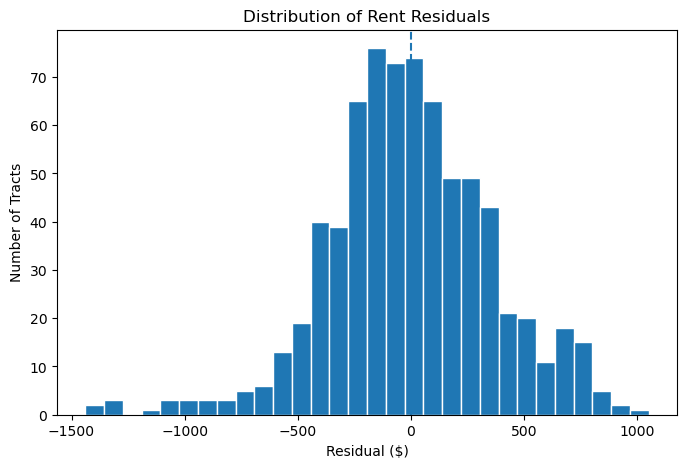

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(residual_results['residual'], bins=30, edgecolor='white')
plt.axvline(0, linestyle='--')
plt.xlabel('Residual ($)')
plt.ylabel('Number of Tracts')
plt.title('Distribution of Rent Residuals')
plt.show()

The distribution is pretty normal, but it's slightly left skewed with a number of predictions below the actual price -- just like what we saw in the scatterplot earlier. I'm going to look at the bottom 10% to investigate.

In [21]:
# using the bottom 10% of residuals as a first-pass screening group
residual_cutoff = residual_results['residual'].quantile(0.10)

residual_results['strong_negative_residual'] = (
    residual_results['residual'] <= residual_cutoff)

print('10% residual cutoff:', round(residual_cutoff, 2))
print('Flagged tracts:', residual_results['strong_negative_residual'].sum())

10% residual cutoff: -414.49
Flagged tracts: 73


### Next steps

I’m using the bottom 10% of residuals for a first round of screening. The cutoff is around -$415, with 73 tracts where actual rent is much lower than the model expected.
Since these stand out,I want to compare once I add the neighborhood clusters.


In [22]:
k_results = []

for k in range(2, 9):    # using a loop so I can try different options without writing code every time
    kmeans = KMeans(
        n_clusters=k,        # number of neighborhood groups
        random_state=42,
        n_init=20)            # runs K-means multiples times and keeps the best result

    labels = kmeans.fit_predict(X_cluster)

    k_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_cluster, labels)})

k_results = pd.DataFrame(k_results)
k_results.round(3)

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is k

,k,inertia,silhouette
0,2,11571.234,0.183
1,3,10334.279,0.181
2,4,9488.886,0.142
3,5,8842.210,0.134
4,6,8415.319,0.139
5,7,8090.337,0.140
6,8,7843.531,0.125


Inertia: how tightly packed the clusters are; the lower the better

Silhouette: 1 is distinct, 0 means a lot of overlap between clusters

The silhouette is low across the board, so there aren't super clean groups that I can differentiate. 

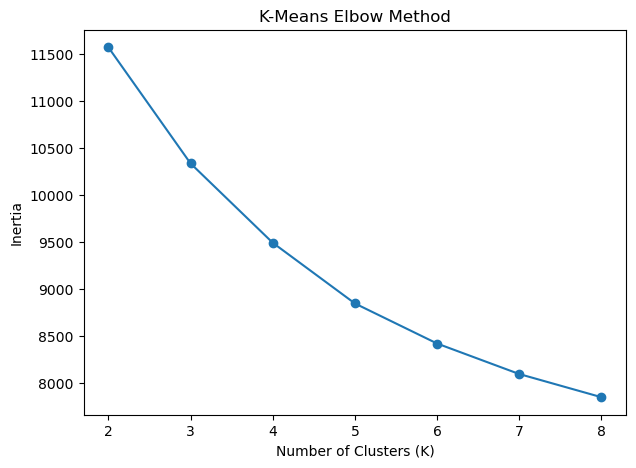

In [23]:
# plotting inertia to look for the elbow
plt.figure(figsize=(7, 5))
plt.plot(k_results['k'], k_results['inertia'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.show()

There's no clear elbow - not very helpful.

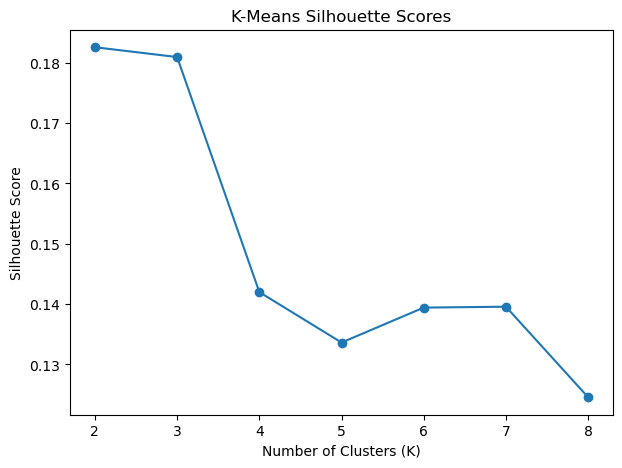

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(k_results['k'], k_results['silhouette'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Silhouette Scores')
plt.show()

The silhouette score has a sharp drop after 3, so I'll stick to 3 clusters and see how I can identify them. But this plot is basically telling me there's a lot of overlap between the tracts based on the data provided. In another version, I might consider using different features, or more features to help create more distinct clusters. 

In [25]:
kmeans_final = KMeans(
    n_clusters=3, # set to 3 clusters
    random_state=42,
    n_init=20)

cluster_labels = kmeans_final.fit_predict(X_cluster)

pd.Series(cluster_labels).value_counts().sort_index()

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0    316
1    270
2    141
Name: count, dtype: int64

In [26]:
# adding cluster labels
cluster_profile = model_data.copy()
cluster_profile['cluster'] = cluster_labels

cluster_summary = cluster_profile.groupby('cluster')[features].mean().round(2)

cluster_summary.T

cluster,0,1,2
walkability_index,9.42,13.48,15.10
public_transit_commute_rate,0.63,2.96,3.20
no_vehicle_rate,2.54,6.91,8.96
work_from_home_rate,24.12,10.79,24.99
climate_loss_risk_score,61.80,35.60,46.47
heat_risk_score,43.30,43.42,23.21
flood_risk_score,67.19,50.75,43.12
wildfire_risk_score,78.62,22.39,15.83
social_vulnerability_score,29.42,51.99,37.28
school_academic_score,3.31,2.73,3.49


In [27]:
cluster_summary = cluster_profile.groupby('cluster')[features].mean().T.round(2)

cluster_summary['min'] = model_data[features].min().round(2)
cluster_summary['max'] = model_data[features].max().round(2)

cluster_summary

cluster,0,1,2,min,max
walkability_index,9.42,13.48,15.10,3.50,19.50
public_transit_commute_rate,0.63,2.96,3.20,0.00,22.30
no_vehicle_rate,2.54,6.91,8.96,0.00,48.40
work_from_home_rate,24.12,10.79,24.99,0.50,53.90
climate_loss_risk_score,61.80,35.60,46.47,1.76,99.99
heat_risk_score,43.30,43.42,23.21,5.87,91.63
flood_risk_score,67.19,50.75,43.12,2.29,99.86
wildfire_risk_score,78.62,22.39,15.83,0.00,100.00
social_vulnerability_score,29.42,51.99,37.28,9.21,98.59
school_academic_score,3.31,2.73,3.49,1.50,5.00


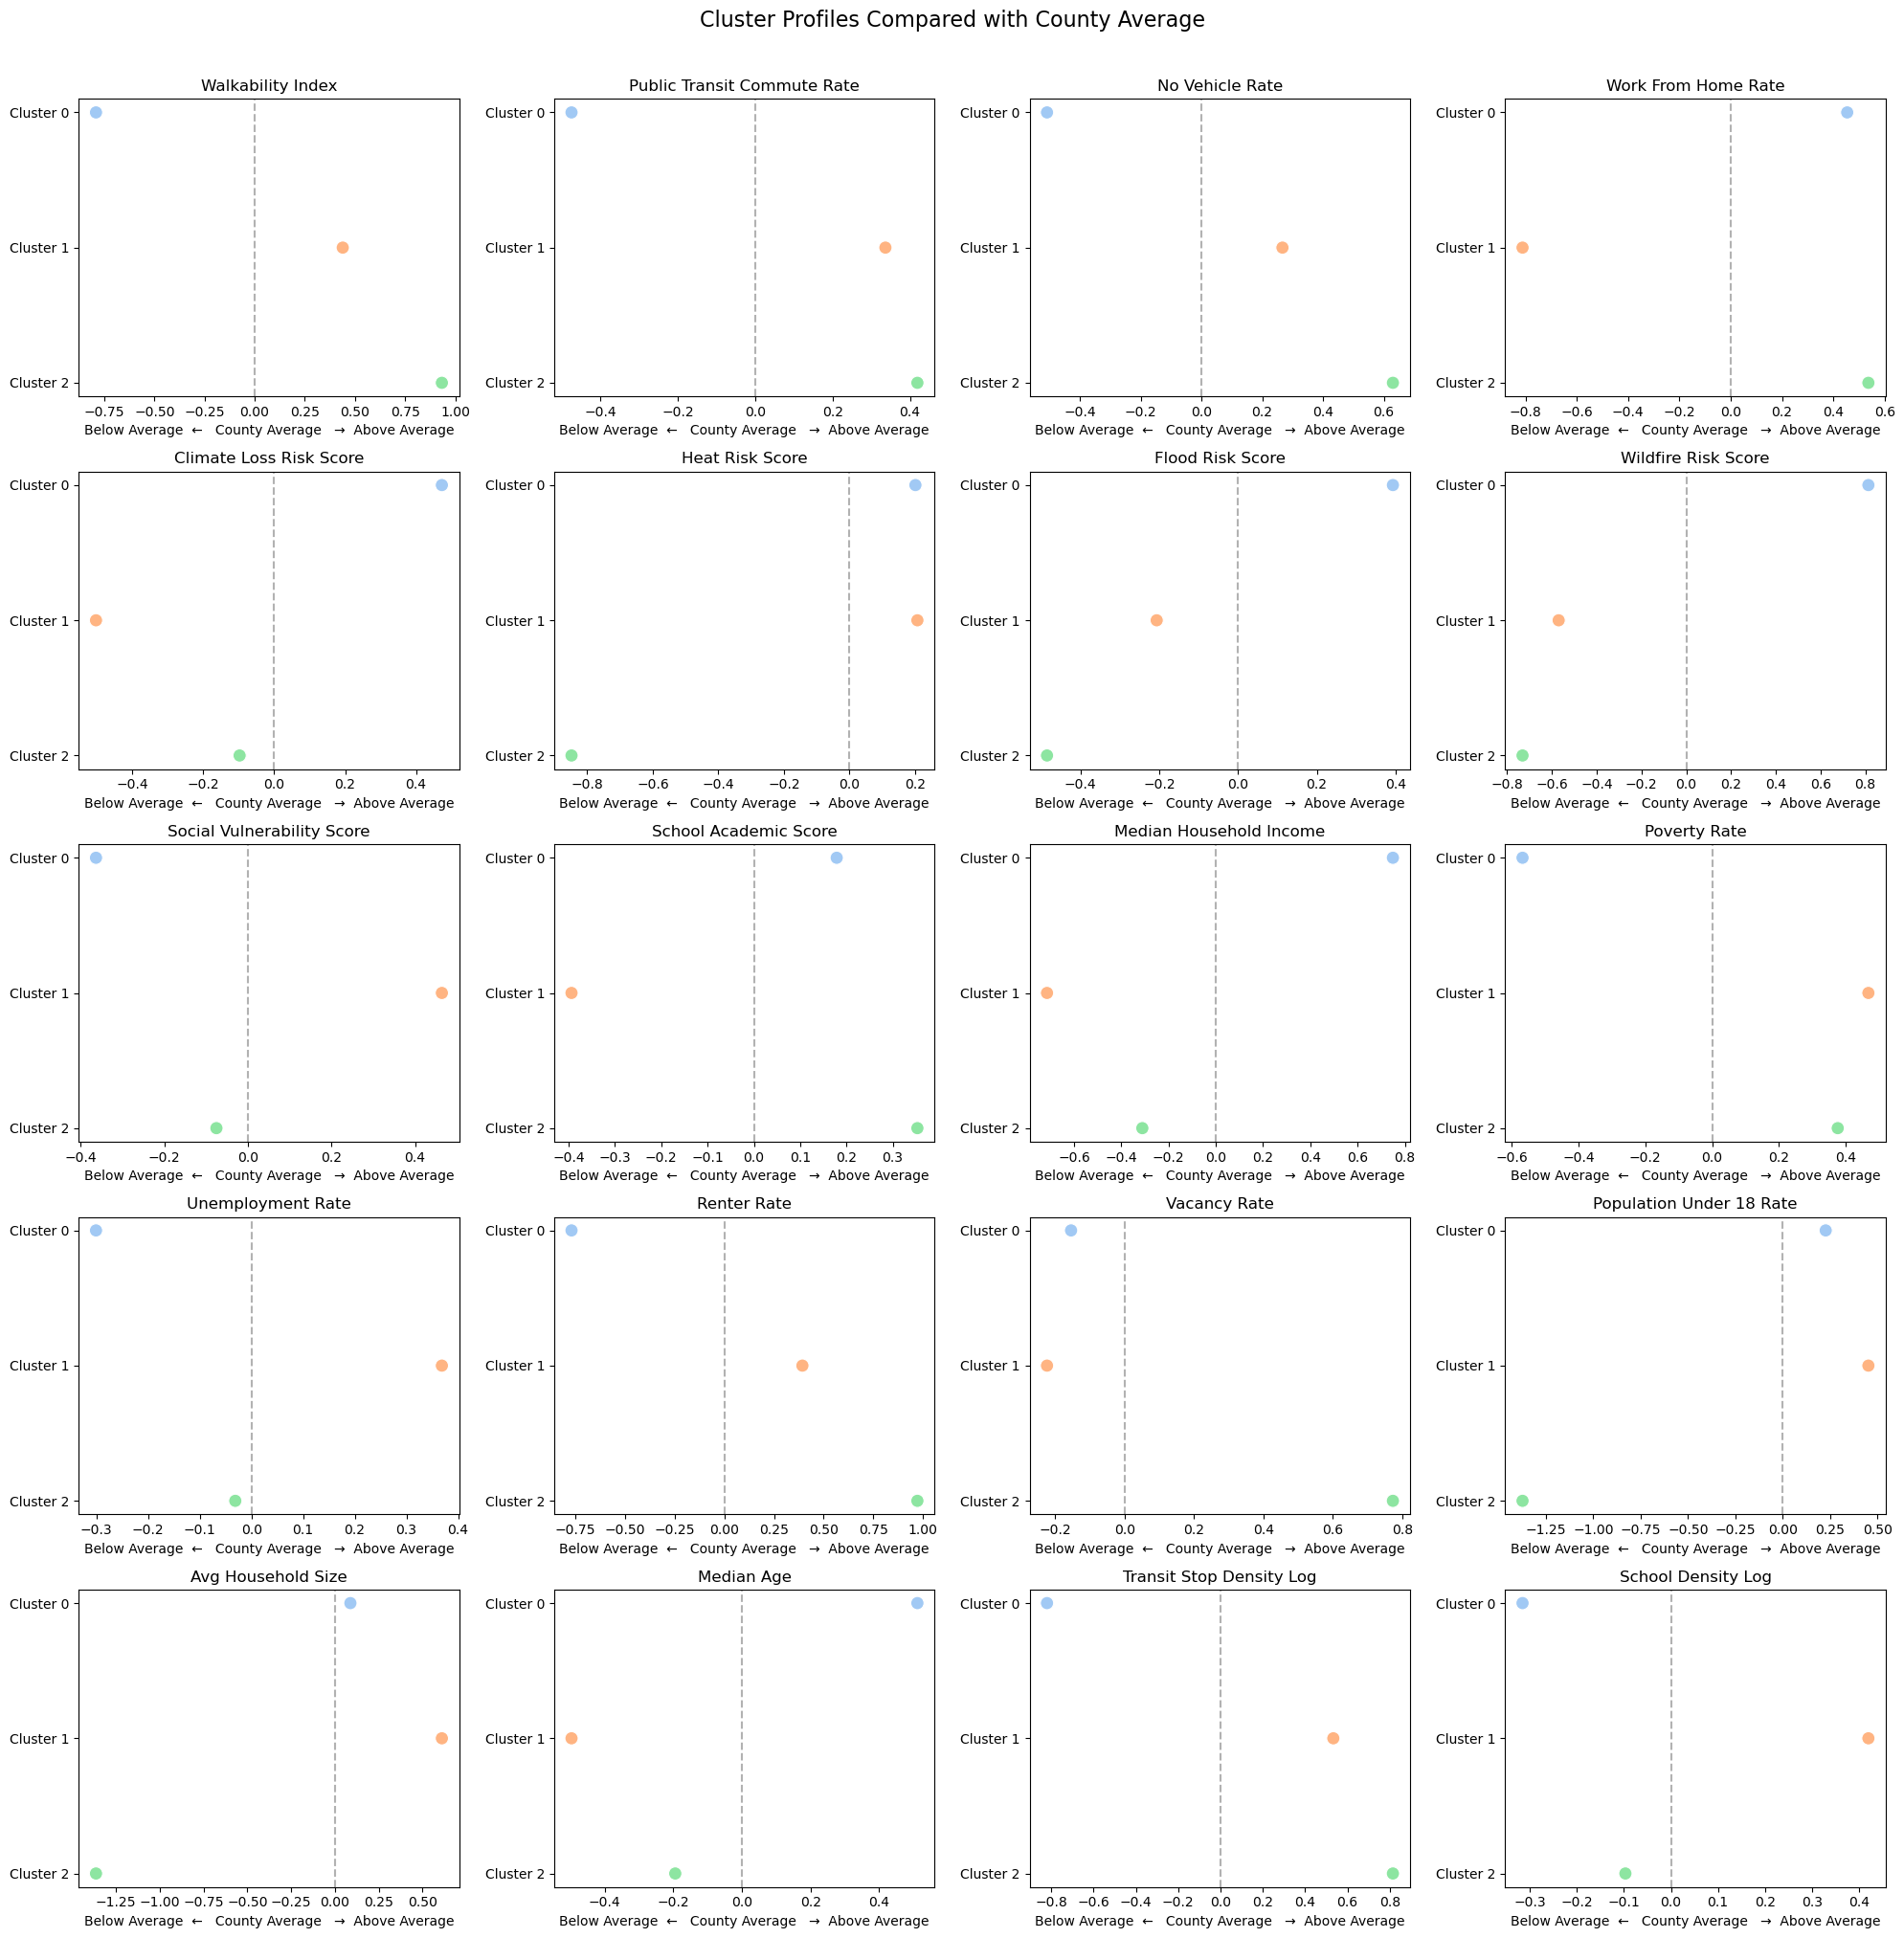

In [28]:
# plotting to visually see where each cluster stands in relation to the countywide average
cluster_scaled = pd.DataFrame(X_cluster, columns=features)
cluster_scaled['cluster'] = cluster_labels

profile_scaled = cluster_scaled.groupby('cluster')[features].mean().T

fig, axes = plt.subplots(5,4, figsize=(20, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    sns.scatterplot(
        x=profile_scaled.loc[feature].values,
        y=['Cluster 0', 'Cluster 1', 'Cluster 2'],
        hue=['Cluster 0', 'Cluster 1', 'Cluster 2'],
        palette='pastel',
        s=100,
        legend=False,
        ax=ax)

    ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Below Average  ←   County Average   →  Above Average')
    ax.set_ylabel('')

plt.suptitle('Cluster Profiles Compared with County Average', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Clustering

   <b>Cluster 0: Affluent Suburban Families - </b> “suburban / higher-income / family-oriented”. Below average in walkability, transit use, renter rate, social vulnerability, poverty, and unemployment. Average in household income, age, household size, children, climate loss risk, flood risk, and especially wildfire risk. It also has higher work-from-home rates.

   <b>Cluster 1: Transit-Reliant Family Renters - </b>“lower-income / transit-reliant / family renter”. Above average in transit use, no-vehicle households, renter rate, social vulnerability, poverty, unemployment, and population under 18. It’s below average in income, work-from-home, school academic score, and wildfire risk.

   <b>Cluster 2: Urban Renters - </b>“urban renter / small-household / high-access” tracts. It has the highest walkability, transit, no-vehicle rate, renter rate, vacancy, and transit-stop density. Well below average in household size and children, with lower climate, heat, flood, and wildfire risk. Income is somewhat below average, but not as low as Cluster 1.

In [29]:
residual_results['cluster'] = cluster_labels

cluster_outcomes = residual_results.groupby('cluster').agg(
    tract_count=('tract_id', 'count'),
    avg_actual_rent=('estimated_median_gross_rent', 'mean'),
    avg_predicted_rent=('predicted_rent', 'mean'),
    avg_residual=('residual', 'mean'),
    strong_negative_count=('strong_negative_residual', 'sum'))

cluster_outcomes['strong_negative_rate'] = (
    cluster_outcomes['strong_negative_count'] / cluster_outcomes['tract_count'])

cluster_outcomes.round(2)

,tract_count,avg_actual_rent,avg_predicted_rent,avg_residual,strong_negative_count,strong_negative_rate
cluster,,,,,,
0,316,2645.06,2633.77,11.29,41,0.13
1,270,2082.21,2102.70,-20.49,21,0.08
2,141,2326.43,2337.84,-11.40,11,0.08


In [30]:
# naming clusters based on their strongest characteristics (think Claritas segment finder)
cluster_names = {
    0: 'Affluent Suburban Families',
    1: 'Transit-Reliant Family Renters',
    2: 'Urban Renters'}

residual_results['cluster_name'] = residual_results['cluster'].map(cluster_names)

residual_results[['cluster', 'cluster_name']].drop_duplicates().sort_values('cluster')

,cluster,cluster_name
0,0,Affluent Suburban Families
20,1,Transit-Reliant Family Renters
1,2,Urban Renters


In [31]:
safety_info = pd.read_csv(
    '../data/processed/master_residential_tract_features_final_eda.csv')[['tract_id', 'sdpd_jurisdiction_flag', 'safety_score']]

final_results = residual_results.merge(
    safety_info,
    on='tract_id',
    how='left')

final_results[
    ['tract_id', 'tract_name', 'estimated_median_gross_rent', 'predicted_rent',
     'residual', 'cluster', 'cluster_name',
     'sdpd_jurisdiction_flag', 'safety_score']].head()

,tract_id,tract_name,estimated_median_gross_rent,predicted_rent,residual,cluster,cluster_name,sdpd_jurisdiction_flag,safety_score
0,6073000100,Census Tract 1; San Diego County; California,2941.5,3082.306486,-140.806486,0,Affluent Suburban Families,1,31.241473
1,6073000201,Census Tract 2.01; San Diego County; California,2407.0,2374.972787,32.027213,2,Urban Renters,1,27.066849
2,6073000202,Census Tract 2.02; San Diego County; California,1992.0,2365.936305,-373.936305,2,Urban Renters,1,13.335607
3,6073000301,Census Tract 3.01; San Diego County; California,1945.0,2343.646441,-398.646441,2,Urban Renters,1,21.002729
4,6073000302,Census Tract 3.02; San Diego County; California,2412.0,2177.950192,234.049808,2,Urban Renters,1,7.175989


In [32]:
top_by_cluster = (
    final_results[final_results['strong_negative_residual']]
    .sort_values(['cluster', 'residual'])
    .groupby('cluster')
    .head(5))

top_by_cluster[
    ['tract_id', 'tract_name', 'cluster_name',
     'estimated_median_gross_rent', 'predicted_rent', 'residual',
     'sdpd_jurisdiction_flag', 'safety_score']].round(1)

,tract_id,tract_name,cluster_name,estimated_median_gross_rent,predicted_rent,residual,sdpd_jurisdiction_flag,safety_score
358,6073013422,Census Tract 134.22; San Diego County; California,Affluent Suburban Families,1337.0,2776.4,-1439.4,0,74.6
705,6073021001,Census Tract 210.01; San Diego County; California,Affluent Suburban Families,629.0,2019.0,-1390.0,0,74.6
413,6073015602,Census Tract 156.02; San Diego County; California,Affluent Suburban Families,1180.0,2521.2,-1341.2,0,74.6
694,6073020801,Census Tract 208.01; San Diego County; California,Affluent Suburban Families,1213.0,2539.5,-1326.5,0,74.6
655,6073020044,Census Tract 200.44; San Diego County; California,Affluent Suburban Families,1754.0,3057.6,-1303.6,0,74.6
67,6073003115,Census Tract 31.15; San Diego County; California,Transit-Reliant Family Renters,969.0,2115.7,-1146.7,1,17.3
58,6073003103,Census Tract 31.03; San Diego County; California,Transit-Reliant Family Renters,1656.0,2409.6,-753.6,1,19.5
723,6073021900,Census Tract 219; San Diego County; California,Transit-Reliant Family Renters,1221.0,1914.8,-693.8,0,40.9
49,6073002804,Census Tract 28.04; San Diego County; California,Transit-Reliant Family Renters,1532.0,2225.2,-693.2,1,18.6
64,6073003112,Census Tract 31.12; San Diego County; California,Transit-Reliant Family Renters,1633.0,2323.1,-690.1,1,20.2


In [33]:
# filtering for SDPD data
top_sdpd = (
    final_results[
        (final_results['strong_negative_residual']) &
        (final_results['sdpd_jurisdiction_flag'] == 1)]
    .sort_values(['cluster', 'residual'])
    .groupby('cluster')
    .head(5))

top_sdpd[
    ['tract_id', 'tract_name', 'cluster_name',
     'estimated_median_gross_rent', 'predicted_rent', 'residual',
     'safety_score']].round(1)

,tract_id,tract_name,cluster_name,estimated_median_gross_rent,predicted_rent,residual,safety_score
501,6073017065,Census Tract 170.65; San Diego County; California,Affluent Suburban Families,1930.0,3021.8,-1091.8,37.1
195,6073008367,Census Tract 83.67; San Diego County; California,Affluent Suburban Families,1618.0,2680.5,-1062.5,37.3
691,6073020710,Census Tract 207.10; San Diego County; California,Affluent Suburban Families,1438.0,2426.5,-988.5,64.0
262,6073009805,Census Tract 98.05; San Diego County; California,Affluent Suburban Families,1821.0,2440.5,-619.5,36.8
252,6073009602,Census Tract 96.02; San Diego County; California,Affluent Suburban Families,2207.0,2795.7,-588.7,29.0
67,6073003115,Census Tract 31.15; San Diego County; California,Transit-Reliant Family Renters,969.0,2115.7,-1146.7,17.3
58,6073003103,Census Tract 31.03; San Diego County; California,Transit-Reliant Family Renters,1656.0,2409.6,-753.6,19.5
49,6073002804,Census Tract 28.04; San Diego County; California,Transit-Reliant Family Renters,1532.0,2225.2,-693.2,18.6
64,6073003112,Census Tract 31.12; San Diego County; California,Transit-Reliant Family Renters,1633.0,2323.1,-690.1,20.2
78,6073003301,Census Tract 33.01; San Diego County; California,Transit-Reliant Family Renters,1562.0,2096.9,-534.9,4.7


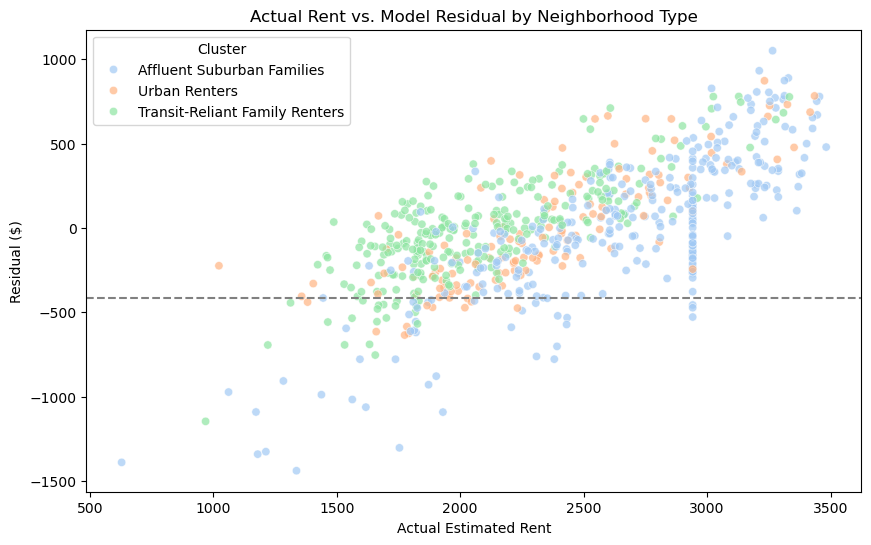

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_results,
    x='estimated_median_gross_rent',
    y='residual',
    hue='cluster_name',
    palette='pastel',
    alpha=0.7)

plt.axhline(residual_cutoff, linestyle='--', color='gray')
plt.xlabel('Actual Estimated Rent')
plt.ylabel('Residual ($)')
plt.title('Actual Rent vs. Model Residual by Neighborhood Type')
plt.legend(title='Cluster')
plt.show()

### Rent Residuals by Neighborhood Type

Most tracts are close to the model’s expected rent, but the strongest negative residuals are concentrated at low "actual rent levels".

Affluent Suburban Family tracts include some of the largest negative residuals, while Urban Renter and Transit-Reliant Family Renter tracts are more concentrated around the middle.

The three clusters overlap quite a bit, so neighborhood type doesn’t explain whether rent will fall above or below the model’s expectation. The residuals seem more useful as an additional screening layer than as something tied to one specific cluster.


In [35]:
# checking that the final workflow still reproduces the main modeling results
print('Linear test R²:', round(linear_metrics['test_r2'], 3))
print('Linear test RMSE:', round(linear_metrics['test_rmse'], 1))
print('RF test R²:', round(rf_metrics['test_r2'], 3))
print('RF test RMSE:', round(rf_metrics['test_rmse'], 1))
print('Residual cutoff:', round(residual_cutoff, 1))
print('Cluster counts:')
print(pd.Series(cluster_labels).value_counts().sort_index())

Linear test R²: 0.566
Linear test RMSE: 364.4
RF test R²: 0.535
RF test RMSE: 377.4
Residual cutoff: -414.5
Cluster counts:
0    316
1    270
2    141
Name: count, dtype: int64


In [36]:
final_results.to_csv(
    '../data/processed/final_modeling_results.csv',
    index=False)

In [37]:
# saving the final model comparison after RF cross-validation tuning
model_comparison.to_csv(
    '../data/processed/model_metrics.csv',
    index=False)

display(model_comparison.round(3))

,model,train_r2,test_r2,test_rmse,test_mae
0,Linear Regression,0.504,0.566,364.386,277.743
1,Tuned Random Forest,0.696,0.535,377.405,281.137


In [39]:
rf_best_params = pd.DataFrame([rf_grid.best_params_])
rf_best_params['best_cv_rmse'] = round(-rf_grid.best_score_, 2)
rf_best_params.to_csv('../data/processed/rf_best_hyperparameters.csv', index=False)

rf_best_params

,max_depth,min_samples_leaf,n_estimators,best_cv_rmse
0,12,10,500,372.15


These hypertuning parameters got me the best score with RF, although the overall performance was lower than LR. 
    

In [40]:
linear_importance.sort_values('importance', ascending=False).to_csv(
    '../data/processed/linear_regression_coefficients.csv', index=False)

print('Linear Regression intercept:', round(linear_model.intercept_, 2))

Linear Regression intercept: 2383.76


The intercept tells me the predicted price if every feature is at the countywide aveerage - so it's essentially the baseline price for a perfectly "average" tract (since I used the standard scalar). All of the coefficients and their values (negative or positive) moves the price from that point then adjusts up or down from there depending on how far a specific tract's features sit from the average.

# Modeling Summary

Linear Regression was the best regression model for this project.

* R2 of 0.57
* RMSE around `$364`
* MAE around `$278`

I tuned the Random Forest using 5-fold cross-validation (CVGridSearch) which helped the model from overfitting (older RF model, removed from this notebook). The turned RF still didn't meet the baseline model's scores ( R2 of 0.54 and RMSE around $377).

<b>Feature Importance: </b>
Median household income had the strongest positive relationship, and climate loss risk had the strongest negative relationship. Flood risk and school score were also strong positive features.

I looked at linear regression distribution and pulled the bottom 10% (73 tracts) where `actual rent` was at least about $415 lower than the model predicted.

Then I did clustering to help define 3 neighborhood groups: Affluent Suburban Families, Transit-Reliant Family Renters, and Urban Renters. The silhouette scores were fairly low, so there was a bit of overlap, but there were a few key differentiators like median income, transit access, household size, and walkability. My goal with this was to create similar identities to those like 'Claritas Segment Finders' where the describe different household types and describe their income levels, education background, purchasing habits, etc so markets can identify their ideal customer base. 

Another model that I wanted to base this exercise on was Local Logic, where they have various scores (schools, walkability, climate risk factors, etc) for a given location to help consumers understand different neighborhood qualities. 

Together, the clusters and regression residuals give me two different ways to narrow down tracts for deeper research. This model isn't advanced enough to determine what tracts might be a good opportunity, but it can help identify features and expose tracts that are priced lower than a prediction. If it were to be used as a screening tool, there would still need to be more research (site-level feasibility would still need zoning, parcel, construction cost, market, and etc).